In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import os
import math
import random
import time
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader, random_split
from torch.nn.utils.rnn import pad_sequence
from collections import Counter
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
import re

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


### DATAI LOADING

In [ ]:
def load_data(path):
    pairs = []

    with open(path, encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split("\t")
            if len(parts) != 2:
                continue
            src, trg = parts
            pairs.append((src, trg))

    return pairs


file_path = "/content/drive/MyDrive/Deep Learning/Exp7/spa.txt"
base_path = "/content/drive/MyDrive/Deep Learning/Exp7"
os.makedirs(base_path, exist_ok=True)

pairs = load_data(file_path)

print("Total sentences:", len(pairs))

Total sentences: 118121


In [ ]:
test_size = int(0.1 * len(pairs))
val_size = int(0.1 * len(pairs))

test_pairs = pairs[:test_size]
val_pairs = pairs[test_size:test_size + val_size]
train_pairs = pairs[test_size + val_size:]

print("Training Data:", len(train_pairs))
print("Validation Data:", len(val_pairs))
print("Testing Data:", len(test_pairs))

Training Data: 94497
Validation Data: 11812
Testing Data: 11812


In [ ]:
EMBEDDINGS = 128
HEADS = 8
FC_SIZE = 2048
DROPOUT = 0.1
ENCODERS = 3
DECODERS = 3
EPOCHS = 100

### MAKING VOCABULARY

In [ ]:
SOS_TOKEN = "<sos>"
EOS_TOKEN = "<eos>"
PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"

def tokenize(text):
    text = text.lower().strip()
    text = text.replace("’", "'")
    text = re.sub(r"[^\w\s]", "", text)
    return text.split()

class Vocabulary:
    def __init__(self):
        self.word2idx = {PAD_TOKEN:0, SOS_TOKEN:1, EOS_TOKEN:2, UNK_TOKEN:3}
        self.idx2word = {v: k for k, v in self.word2idx.items()}
        self.count = len(self.word2idx)

    def __len__(self):
        return self.count

    def build(self, sentences):
        counter = Counter()
        for s in sentences:
            counter.update(tokenize(s))
        for word in sorted(counter.keys()):
            if word not in self.word2idx:
                self.word2idx[word] = self.count
                self.idx2word[self.count] = word
                self.count += 1

    def numericalize(self, sentence):
        index = [self.word2idx.get(w,self.word2idx[UNK_TOKEN]) for w in tokenize(sentence)]
        index = ([self.word2idx[SOS_TOKEN]] + index + [self.word2idx[EOS_TOKEN]])
        return index

In [ ]:
src_vocab = Vocabulary()
trg_vocab = Vocabulary()

src_vocab.build([p[0] for p in train_pairs])
trg_vocab.build([p[1] for p in train_pairs])

SRC_PAD_IDX = src_vocab.word2idx[PAD_TOKEN]
TGT_PAD_IDX = trg_vocab.word2idx[PAD_TOKEN]

print("Source Vocabulary Size:", src_vocab.count)
print("Target Vocabulary Size:", trg_vocab.count)

Source Vocabulary Size: 13073
Target Vocabulary Size: 24121


### TRANSFORMER ARCHITECURE ELEMENTS

In [ ]:
class CustomDataset(Dataset):
    def __init__(self, pairs):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        src, trg = self.pairs[idx]
        src_seq = src_vocab.numericalize(src)
        trg_seq = trg_vocab.numericalize(trg)
        return torch.tensor(src_seq), torch.tensor(trg_seq)

def collate_fn(batch):
    src_batch, trg_batch = zip(*batch)

    src_batch = pad_sequence(src_batch, batch_first=True, padding_value=0)
    trg_batch = pad_sequence(trg_batch, batch_first=True, padding_value=0)

    return src_batch, trg_batch

train_loader = DataLoader(CustomDataset(train_pairs), batch_size=64, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(CustomDataset(val_pairs), batch_size=64, collate_fn=collate_fn)
test_loader = DataLoader(CustomDataset(test_pairs), batch_size=1, collate_fn=collate_fn)

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, EMBEDDINGS, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, EMBEDDINGS)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, EMBEDDINGS, 2)*(-math.log(10000.0) / EMBEDDINGS))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

In [ ]:
class MultiAttention(nn.Module):
    def __init__(self, EMBEDDINGS, HEADS):
        super().__init__()
        assert EMBEDDINGS % HEADS == 0
        self.d_k = EMBEDDINGS // HEADS
        self.HEADS = HEADS
        self.q_linear = nn.Linear(EMBEDDINGS, EMBEDDINGS)
        self.k_linear = nn.Linear(EMBEDDINGS, EMBEDDINGS)
        self.v_linear = nn.Linear(EMBEDDINGS, EMBEDDINGS)
        self.fc = nn.Linear(EMBEDDINGS, EMBEDDINGS)
    def forward(self, q, k, v, mask=None):
        B = q.size(0)
        Q = self.q_linear(q)
        K = self.k_linear(k)
        V = self.v_linear(v)
        Q = Q.view(B, -1, self.HEADS, self.d_k).transpose(1,2)
        K = K.view(B, -1, self.HEADS, self.d_k).transpose(1,2)
        V = V.view(B, -1, self.HEADS, self.d_k).transpose(1,2)
        scores = torch.matmul(Q, K.transpose(-2,-1)) / math.sqrt(self.d_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        attn = torch.softmax(scores, dim=-1)
        context = torch.matmul(attn, V)
        context = context.transpose(1,2).contiguous().view(B, -1, self.HEADS*self.d_k)
        return self.fc(context)

In [ ]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.attn = MultiAttention(EMBEDDINGS, HEADS)
        self.ff = nn.Sequential(nn.Linear(EMBEDDINGS, FC_SIZE),nn.ReLU(),nn.Linear(FC_SIZE, EMBEDDINGS))
        self.norm1 = nn.LayerNorm(EMBEDDINGS)
        self.norm2 = nn.LayerNorm(EMBEDDINGS)
        self.dropout = nn.Dropout(DROPOUT)

    def forward(self, x, mask):
        attn_out = self.attn(x,x,x,mask)
        x = self.norm1(x + self.dropout(attn_out))
        ff_out = self.ff(x)
        x = self.norm2(x + self.dropout(ff_out))
        return x

In [ ]:
class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.self_attn = MultiAttention(EMBEDDINGS, HEADS)
        self.cross_attn = MultiAttention(EMBEDDINGS, HEADS)
        self.ff = nn.Sequential(nn.Linear(EMBEDDINGS, FC_SIZE),nn.ReLU(),nn.Linear(FC_SIZE, EMBEDDINGS))
        self.norm1 = nn.LayerNorm(EMBEDDINGS)
        self.norm2 = nn.LayerNorm(EMBEDDINGS)
        self.norm3 = nn.LayerNorm(EMBEDDINGS)
        self.dropout = nn.Dropout(DROPOUT)

    def forward(self, x, enc_out, src_mask, tgt_mask):
        x = self.norm1(x + self.dropout(self.self_attn(x,x,x,tgt_mask)))
        x = self.norm2(x + self.dropout(self.cross_attn(x,enc_out,enc_out,src_mask)))
        x = self.norm3(x + self.dropout(self.ff(x)))
        return x

In [ ]:
class Architecture(nn.Module):
    def __init__(self):
        super().__init__()
        self.src_embed = nn.Embedding(len(src_vocab), EMBEDDINGS)
        self.tgt_embed = nn.Embedding(len(trg_vocab), EMBEDDINGS)
        self.pos_enc = PositionalEncoding(EMBEDDINGS)
        self.encoder = nn.ModuleList([Encoder() for _ in range(ENCODERS)])
        self.decoder = nn.ModuleList([Decoder() for _ in range(DECODERS)])
        self.fc_out = nn.Linear(EMBEDDINGS, len(trg_vocab))
    def make_src_mask(self, src):
        return (src != SRC_PAD_IDX).unsqueeze(1).unsqueeze(2)
    def make_tgt_mask(self, tgt):
        B, T = tgt.shape
        pad_mask = (tgt != TGT_PAD_IDX).unsqueeze(1).unsqueeze(2)
        causal_mask = torch.tril(torch.ones((T,T))).bool().to(device)
        return pad_mask & causal_mask
    def forward(self, src, tgt):
        src_mask = self.make_src_mask(src)
        tgt_mask = self.make_tgt_mask(tgt)
        src = self.pos_enc(self.src_embed(src))
        tgt = self.pos_enc(self.tgt_embed(tgt))
        for layer in self.encoder:
            src = layer(src, src_mask)
        enc_out = src
        for layer in self.decoder:
            tgt = layer(tgt, enc_out, src_mask, tgt_mask)
        return self.fc_out(tgt)

In [ ]:
model = Architecture().to(device)
optimizer = optim.Adam(model.parameters(),lr=1e-4)
criterion = nn.CrossEntropyLoss(ignore_index=TGT_PAD_IDX)

### TRAINING LOOP

In [ ]:
train_losses, val_losses = [], []
train_bleus, val_bleus = [], []

for epoch in range(EPOCHS):
    start_time = time.time()
    model.train()

    total_loss = 0
    hypotheses, references = [], []

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}")

    for src, trg in pbar:
        src, trg = src.to(device), trg.to(device)
        optimizer.zero_grad()
        output = model(src, trg[:, :-1])
        loss = criterion(output.reshape(-1, output.shape[-1]), trg[:,1:].reshape(-1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        preds = output.argmax(-1).cpu().numpy()
        trg_seq = trg[:,1:].cpu().numpy()

        for pred_sent, ref_sent in zip(preds, trg_seq):
            pred_words = [trg_vocab.idx2word[idx] for idx in pred_sent
                          if idx not in (trg_vocab.word2idx[SOS_TOKEN], TGT_PAD_IDX, trg_vocab.word2idx[EOS_TOKEN])]
            ref_words = [[trg_vocab.idx2word[idx] for idx in ref_sent
                          if idx not in (TGT_PAD_IDX, trg_vocab.word2idx[EOS_TOKEN])]]
            hypotheses.append(pred_words)
            references.append(ref_words)
        pbar.set_postfix(train_loss=loss.item())
    train_bleu = corpus_bleu(references, hypotheses, smoothing_function=SmoothingFunction().method4)
    train_losses.append(total_loss / len(train_loader))
    train_bleus.append(train_bleu)

    model.eval()
    val_loss = 0
    val_hypotheses, val_references = [], []

    with torch.no_grad():
        for src, trg in val_loader:
            src, trg = src.to(device), trg.to(device)
            output = model(src, trg[:, :-1])
            loss = criterion(output.reshape(-1, output.shape[-1]), trg[:,1:].reshape(-1))
            val_loss += loss.item()
            preds = output.argmax(-1).cpu().numpy()
            trg_seq = trg[:,1:].cpu().numpy()
            for pred_sent, ref_sent in zip(preds, trg_seq):
                pred_words = [trg_vocab.idx2word[idx] for idx in pred_sent
                              if idx not in (trg_vocab.word2idx[SOS_TOKEN], TGT_PAD_IDX, trg_vocab.word2idx[EOS_TOKEN])]
                ref_words = [[trg_vocab.idx2word[idx] for idx in ref_sent
                              if idx not in (TGT_PAD_IDX, trg_vocab.word2idx[EOS_TOKEN])]]
                val_hypotheses.append(pred_words)
                val_references.append(ref_words)
    val_loss /= len(val_loader)
    val_bleu = corpus_bleu(val_references, val_hypotheses, smoothing_function=SmoothingFunction().method4)
    val_losses.append(val_loss)
    val_bleus.append(val_bleu)
    print(f"Epoch {epoch+1}: Train Loss: {train_losses[-1]:.4f} Train BLEU: {train_bleus[-1]:.4f} Val Loss: {val_losses[-1]:.4f} Val BLEU: {val_bleus[-1]:.4f}")
save_path = os.path.join(base_path, "exp7_transformer.pt")
torch.save(model.state_dict(), save_path)
print("Saved:", save_path)

Epoch 1: 100%|██████████| 1477/1477 [00:59<00:00, 25.00it/s, train_loss=3.21]


Epoch 1: Train Loss: 2.9851 Train BLEU: 0.1773 Val Loss: 2.5997 Val BLEU: 0.2247


Epoch 2: 100%|██████████| 1477/1477 [00:58<00:00, 25.23it/s, train_loss=2.59]


Epoch 2: Train Loss: 2.6362 Train BLEU: 0.2189 Val Loss: 2.3818 Val BLEU: 0.2598


Epoch 3: 100%|██████████| 1477/1477 [00:57<00:00, 25.78it/s, train_loss=2.21]


...

Epoch 98: Train Loss: 0.1613 Train BLEU: 0.8501 Val Loss: 2.3589 Val BLEU: 0.4003


Epoch 99: 100%|██████████| 1477/1477 [01:01<00:00, 24.01it/s, train_loss=0.195]


Epoch 99: Train Loss: 0.1578 Train BLEU: 0.8547 Val Loss: 2.3654 Val BLEU: 0.3936


Epoch 100: 100%|██████████| 1477/1477 [01:02<00:00, 23.62it/s, train_loss=0.174]


Epoch 100: Train Loss: 0.1565 Train BLEU: 0.8543 Val Loss: 2.3793 Val BLEU: 0.3965
Saved: /content/drive/MyDrive/Deep Learning/Exp7/exp7_transformer.pt


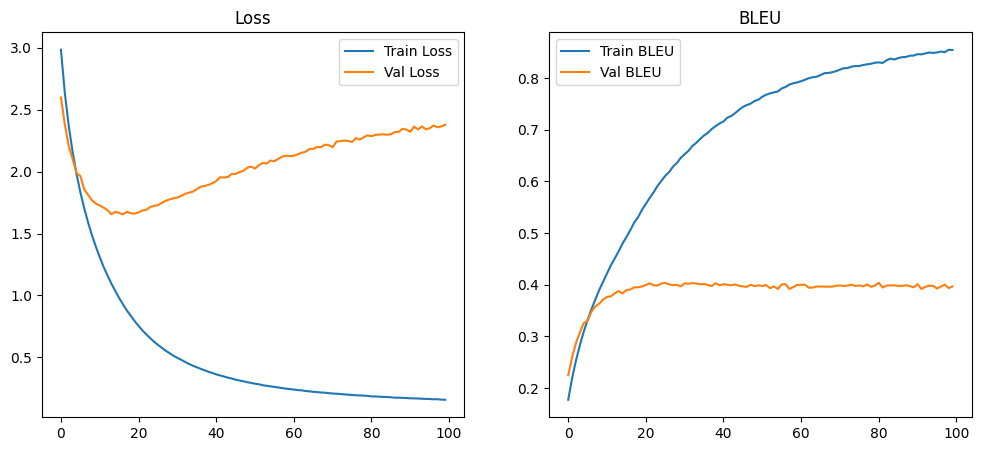

In [ ]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss")
plt.subplot(1,2,2)
plt.plot(train_bleus, label="Train BLEU")
plt.plot(val_bleus, label="Val BLEU")
plt.legend()
plt.title("BLEU")
plt.show()

In [ ]:
model = Architecture().to(device)
model.load_state_dict(torch.load("/content/drive/MyDrive/Deep Learning/Exp7/exp7_transformer.pt", map_location=device))
model.to(device)
model.eval()

Transformer(
  (src_embed): Embedding(13073, 128)
  (tgt_embed): Embedding(24121, 128)
  (pos_enc): PositionalEncoding()
  (encoder): ModuleList(
    (0-2): 3 x EncoderLayer(
      (attn): MultiHeadAttention(
        (q_linear): Linear(in_features=128, out_features=128, bias=True)
        (k_linear): Linear(in_features=128, out_features=128, bias=True)
        (v_linear): Linear(in_features=128, out_features=128, bias=True)
        (fc): Linear(in_features=128, out_features=128, bias=True)
      )
      (ff): Sequential(
        (0): Linear(in_features=128, out_features=2048, bias=True)
        (1): ReLU()
        (2): Linear(in_features=2048, out_features=128, bias=True)
      )
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
  )
  (decoder): ModuleList(
    (0-2): 3 x DecoderLayer(
      (self_attn): MultiHeadAttention(
        (q_linear): Lin

In [ ]:
def compute_bleu(model, max_len=10):
    model.eval()
    references, hypotheses = [], []
    with torch.no_grad():
        for src, trg in test_loader:
            src, trg = src.to(device), trg.to(device)
            src_mask = model.make_src_mask(src)
            enc_out = model.pos_enc(model.src_embed(src))
            for layer in model.encoder:
                enc_out = layer(enc_out, src_mask)
            tgt_indices = torch.tensor([[trg_vocab.word2idx[SOS_TOKEN]]], device=device)
            for _ in range(max_len):
                tgt_mask = model.make_tgt_mask(tgt_indices)
                tgt_embed = model.pos_enc(model.tgt_embed(tgt_indices))
                dec_out = tgt_embed
                for layer in model.decoder:
                    dec_out = layer(dec_out, enc_out, src_mask, tgt_mask)
                out = model.fc_out(dec_out)
                next_word = out[:, -1, :].argmax(-1).unsqueeze(0)
                tgt_indices = torch.cat([tgt_indices, next_word.T], dim=1)
                if next_word.item() == trg_vocab.word2idx[EOS_TOKEN]:
                    break
            pred_words = [trg_vocab.idx2word[idx] for idx in tgt_indices[0].cpu().tolist()
                          if idx not in (trg_vocab.word2idx[SOS_TOKEN], trg_vocab.word2idx[PAD_TOKEN], trg_vocab.word2idx[EOS_TOKEN])]
            ref_words = [trg_vocab.idx2word[idx.item()] for idx in trg[0]
                         if idx.item() not in (trg_vocab.word2idx[SOS_TOKEN], trg_vocab.word2idx[PAD_TOKEN], trg_vocab.word2idx[EOS_TOKEN])]
            hypotheses.append(pred_words)
            references.append([ref_words])
    bleu = corpus_bleu(references, hypotheses, smoothing_function=SmoothingFunction().method4)
    return bleu

In [ ]:
test_bleu = compute_bleu(model)

### FINAL RESULTS

In [ ]:
results = pd.DataFrame({
    "Train BLEU": [train_bleus[-1]],
    "Validation BLEU": [val_bleus[-1]],
    "Test BLEU": [test_bleu]
}).round(4)
results

,Train BLEU,Validation BLEU,Test BLEU
0,0.8543,0.3965,0.2306
